In [1]:
# ================================================
# FP-GROWTH - Instacart Market Basket Analysis
# Ton rôle : Data Scientist (Préparation + EDA + FP-Growth)
# Projet DSTI - Data-Driven Retail Insights
# ================================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

In [3]:
# ====================== 1. CHARGEMENT & ÉCHANTILLONNAGE ======================
print("=== Chargement des données ===")
start_time = time.time()

# Chemins (adapte si besoin)
path = '../Data/'

orders = pd.read_csv(path + 'orders.csv')
prior = pd.read_csv(path + 'order_products__prior.csv')
products = pd.read_csv(path + 'products.csv')
aisles = pd.read_csv(path + 'aisles.csv')
departments = pd.read_csv(path + 'departments.csv')

print(f"Orders : {orders.shape[0]:,} | Prior products : {prior.shape[0]:,}")

=== Chargement des données ===
Orders : 3,421,083 | Prior products : 32,434,489


In [39]:
# === ÉCHANTILLONNAGE (CRUCIAL pour éviter MemoryError) ===
# On prend 50 000 commandes aléatoires (tu peux monter à 100k si tu as 16Go+ RAM)
SAMPLE_SIZE = 300_000
sampled_order_ids = orders['order_id'].sample(n=SAMPLE_SIZE, random_state=42)
prior_sample = prior[prior['order_id'].isin(sampled_order_ids)]

print(f"Échantillon utilisé : {len(sampled_order_ids):,} commandes")

Échantillon utilisé : 300,000 commandes


In [40]:
# ====================== 2. PRÉPARATION DES DONNÉES (EDA) ======================
print("\n=== Préparation & EDA ===")

# Merge pour avoir les noms et départements
df = pd.merge(prior_sample, products[['product_id', 'product_name', 'aisle_id', 'department_id']], 
              on='product_id', how='left')
df = pd.merge(df, aisles, on='aisle_id', how='left')
df = pd.merge(df, departments, on='department_id', how='left')


=== Préparation & EDA ===


In [41]:
# === Simulation de prix (en attendant les data engineers) ===
np.random.seed(42)
products['price'] = np.random.uniform(0.5, 15.0, size=len(products))  # prix réalistes
df = pd.merge(df, products[['product_id', 'price']], on='product_id')

print(f"Prix moyen simulé : {df['price'].mean():.2f} €")

Prix moyen simulé : 7.87 €


In [42]:
# === Création du format transactionnel ===
transactions = df.groupby('order_id')['product_name'].apply(list).reset_index()
transactions_list = transactions['product_name'].tolist()

print(f"Nombre de transactions : {len(transactions_list):,}")
print(f"Exemple de panier : {transactions_list[0][:8]}...")

Nombre de transactions : 282,095
Exemple de panier : ['Gluten Free Mushroom Risotto Bowl', 'Cold-Brew Black Coffee', 'Kale, Apple, Ginger, Romaine, Spinach, Cucumber, Celery, Parsley, Lemon Cold Pressed Juice Beverage', 'Organic Olive Oil  Spray', 'Baby Swiss Slices Cheese', 'Gourmet Mochi Ice Cream Vanilla Bonbons', 'Eucalyptus & Peppermint Body Wash', 'Original Recipe Rice Pudding']...


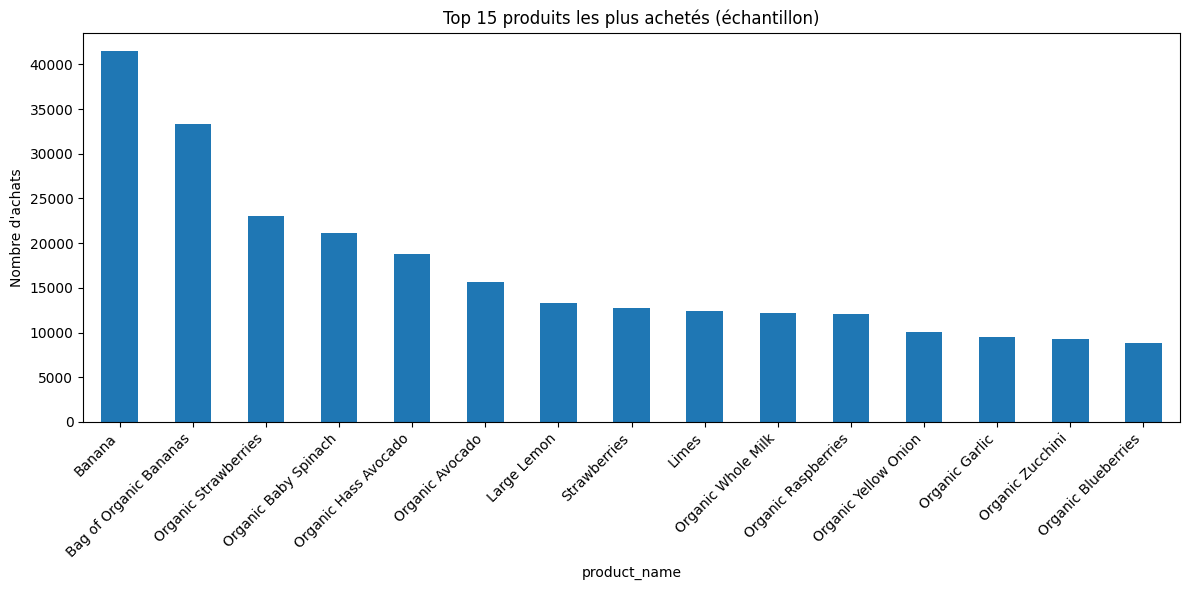

In [43]:
# ====================== 3. EDA VISUELLE (à mettre dans ton notebook) ======================
plt.figure(figsize=(12, 6))
df['product_name'].value_counts().head(15).plot(kind='bar')
plt.title('Top 15 produits les plus achetés (échantillon)')
plt.ylabel('Nombre d\'achats')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Taille moyenne panier : 10.1 produits


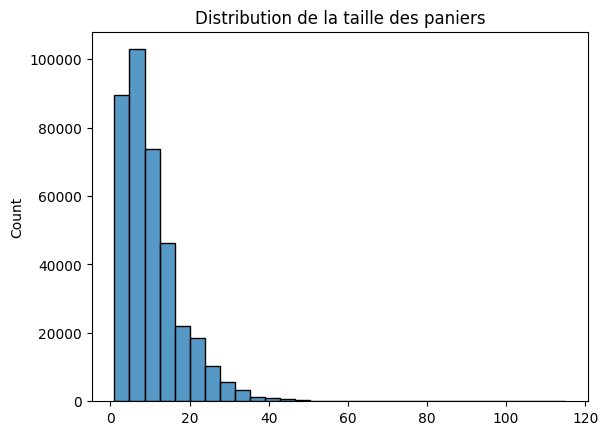

In [37]:
# Taille moyenne des paniers
basket_size = df.groupby('order_id').size()
print(f"Taille moyenne panier : {basket_size.mean():.1f} produits")
sns.histplot(basket_size, bins=30)
plt.title('Distribution de la taille des paniers')
plt.show()

 4. FP-GROWTH 

In [44]:
print("\n=== Exécution FP-Growth ===")
fp_start = time.time()

# Transformation en One-Hot (format requis par mlxtend)
te = TransactionEncoder()
te_ary = te.fit(transactions_list).transform(transactions_list, sparse=True)  # sparse = économie mémoire
df_onehot = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

# Paramètres recommandés pour Instacart
min_support_value = 0.005   # = 0.5% des paniers → environ 250 paniers sur 50k

frequent_itemsets = fpgrowth(df_onehot, 
                             min_support=min_support_value, 
                             use_colnames=True,
                             verbose=1)

print(f"Nombre d'itemsets fréquents trouvés : {len(frequent_itemsets):,}")
print(f"Temps FP-Growth : {time.time() - fp_start:.1f} secondes")


=== Exécution FP-Growth ===
253 itemset(s) from tree conditioned on items ()
0 itemset(s) from tree conditioned on items (Sparkling Natural Mineral Water)
0 itemset(s) from tree conditioned on items (Macaroni & Cheese)
2 itemset(s) from tree conditioned on items (Strawberries)
0 itemset(s) from tree conditioned on items (Strawberries, Banana)
0 itemset(s) from tree conditioned on items (Strawberries, Bag of Organic Bananas)
3 itemset(s) from tree conditioned on items (Organic Blueberries)
0 itemset(s) from tree conditioned on items (Organic Blueberries, Organic Strawberries)
0 itemset(s) from tree conditioned on items (Organic Blueberries, Bag of Organic Bananas)
0 itemset(s) from tree conditioned on items (Organic Blueberries, Banana)
0 itemset(s) from tree conditioned on items (Raspberries)
4 itemset(s) from tree conditioned on items (Organic Cucumber)
0 itemset(s) from tree conditioned on items (Organic Cucumber, Organic Hass Avocado)
0 itemset(s) from tree conditioned on items (Or

In [45]:
# ====================== 5. RÈGLES D'ASSOCIATION ======================
rules = association_rules(frequent_itemsets, 
                          metric="lift", 
                          min_threshold=1.2)

# Ajout de métriques business
rules = rules.sort_values('lift', ascending=False)

# Calcul du revenu estimé par règle (business impact)
def estimate_revenue(row):
    # Prix moyen des antécédents + conséquents
    antecedent_items = list(row['antecedents'])
    consequent_items = list(row['consequents'])
    avg_price_ante = df[df['product_name'].isin(antecedent_items)]['price'].mean()
    avg_price_cons = df[df['product_name'].isin(consequent_items)]['price'].mean()
    return row['support'] * SAMPLE_SIZE * (avg_price_ante + avg_price_cons) * row['confidence']

rules['estimated_revenue_per_100k_orders'] = rules.apply(estimate_revenue, axis=1) * 2  # x2 pour extrapoler

In [46]:
# ====================== 6. RÉSULTATS PRÉCIS (à copier dans ton rapport) ======================
print("\n=== TOP 15 RÈGLES LES PLUS INTÉRESSANTES (triées par Lift) ===")
top_rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 
                   'estimated_revenue_per_100k_orders']].head(15).round(4)

display(top_rules)   # Dans Jupyter ça affiche un beau tableau


=== TOP 15 RÈGLES LES PLUS INTÉRESSANTES (triées par Lift) ===


,antecedents,consequents,support,confidence,lift,estimated_revenue_per_100k_orders
57,frozenset({Organic Cilantro}),frozenset({Limes}),0.0057,0.2594,5.8889,8540.0346
56,frozenset({Limes}),frozenset({Organic Cilantro}),0.0057,0.1283,5.8889,4221.9160
103,frozenset({Organic Yellow Onion}),frozenset({Organic Garlic}),0.0069,0.1931,5.7040,18195.9835
102,frozenset({Organic Garlic}),frozenset({Organic Yellow Onion}),0.0069,0.2035,5.7040,19175.4301
77,frozenset({Large Lemon}),frozenset({Limes}),0.0085,0.1802,4.0907,10834.2023
76,frozenset({Limes}),frozenset({Large Lemon}),0.0085,0.1933,4.0907,11618.7841
110,frozenset({Organic Hass Avocado}),frozenset({Organic Lemon}),0.0064,0.0962,3.5292,5548.4283
111,frozenset({Organic Lemon}),frozenset({Organic Hass Avocado}),0.0064,0.2349,3.5292,13541.1078
107,frozenset({Organic Garlic}),frozenset({Limes}),0.0051,0.1507,3.4206,7592.2297
106,frozenset({Limes}),frozenset({Organic Garlic}),0.0051,0.1158,3.4206,5833.4569


In [13]:
# Export pour ton équipe / dashboard
top_rules.to_csv('fp_growth_top_rules.csv', index=False)
frequent_itemsets.to_csv('fp_growth_frequent_itemsets.csv', index=False)

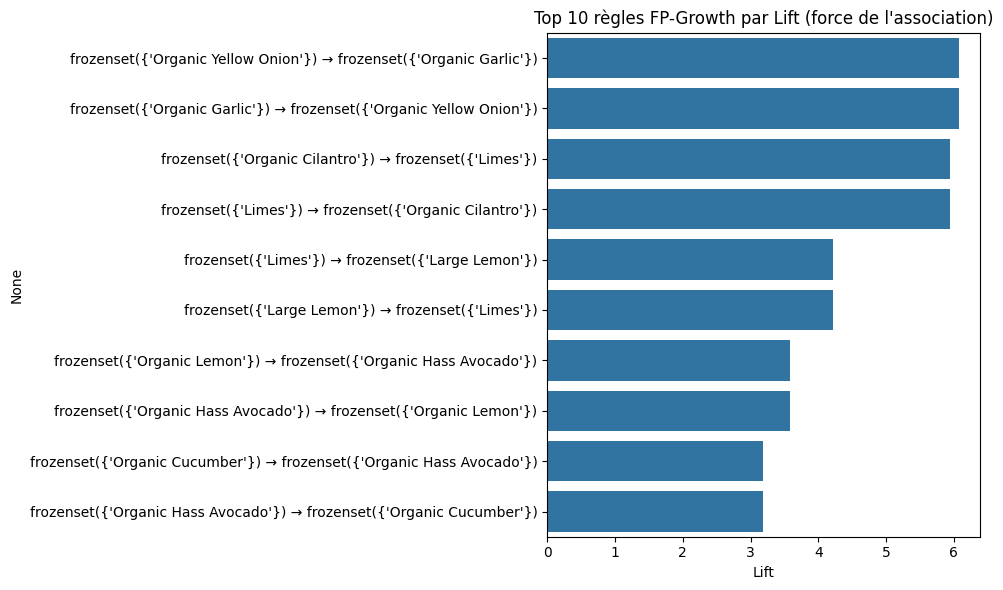

In [25]:
# ====================== 7. VISUALISATION BUSINESS ======================
plt.figure(figsize=(10, 6))
sns.barplot(data=top_rules.head(10), 
            y=top_rules.head(10)['antecedents'].astype(str) + ' → ' + top_rules.head(10)['consequents'].astype(str),
            x='lift')
plt.title('Top 10 règles FP-Growth par Lift (force de l\'association)')
plt.xlabel('Lift')
plt.tight_layout()
plt.show()

In [15]:
print(f"\nTemps total d'exécution : {time.time() - start_time:.1f} secondes")


Temps total d'exécution : 493.2 secondes
